In [8]:
from astropy.table import Table
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
import fitsio
import healpy
from scipy.spatial import cKDTree
from astropy.cosmology import Planck18 as cosmo
import pandas as pd
from astropy.table import Table, vstack
import matplotlib

In [2]:
direc = "/global/cfs/cdirs/desi/survey/catalogs/SV3/mocks/LSS_rea024/fuji/LSScats/1/"
file1 = direc+"ELG_clustering.dat.fits"
file2 = direc+"ELG_full.dat.fits"
file3 = direc+"ELG_full_noveto.dat.fits"

tab1 = Table(fitsio.read(file1))
tab2 = Table(fitsio.read(file2))
tab3 = Table(fitsio.read(file3))

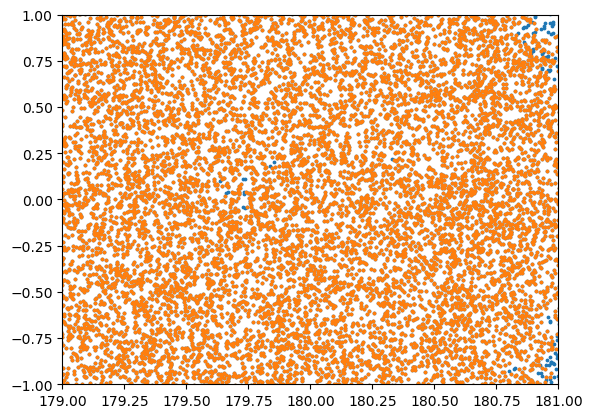

In [14]:
plt.xlim(179,181)
plt.ylim(-1,1)
#plt.scatter(tab1['RA'],tab1['DEC'],s=3)
plt.scatter(tab3['RA'],tab3['DEC'],s=3)
plt.scatter(tab2['RA'],tab2['DEC'],s=3)

In [4]:
file = '/global/cfs/cdirs/desi/survey/catalogs/Y1/mocks/SecondGenMocks/AbacusSummit_v4_2/altmtl0/mock0/LSScats/ELG_LOPnotqso_0_full_HPmapcut.ran.fits'
file2  = '/global/cfs/cdirs/desi//survey/catalogs/Y1/mocks/SecondGenMocks/AbacusSummit_v4_2/mock0/LRG_complete_clustering.dat.fits'
tab = Table(fitsio.read(file))

In [7]:
tab[0]

LOCATION,FIBER,TARGETID,RA,DEC,TILEID,PRIORITY,TSNR2_ELG,TSNR2_LYA,TSNR2_BGS,TSNR2_QSO,TSNR2_LRG,TILELOCID,ZPOSSLOC,GOODHARDLOC,GOODPRI,sort,NTILE,TILES,TILELOCIDS,NOBS_G,NOBS_R,NOBS_Z,MASKBITS,PHOTSYS,FRAC_TLOBS_TILES
int64,int64,int64,float64,float64,int64,int32,float32,float32,float32,float32,float32,int64,bool,bool,bool,int64,int64,str36,str111,int16,int16,int16,int16,str1,float64
525,398,327857698848637143,21.699488025847675,-19.375747955151088,1169,3200,100.323364,100.73031,6014.282,25.910995,72.489075,11690525,True,True,True,2,1,1169,11690511-11690525,9,9,8,0,S,0.49043634190077706


In [4]:
#checking for low NTILE regions
mockdir = "/global/cfs/cdirs/desi/survey/catalogs/Y1/mocks/SecondGenMocks/AbacusSummit_v4_2/mock1/"
efile = mockdir+"LRG_complete_clustering.dat.fits"
lrgtab = Table(fitsio.read(efile))
mockdir = "/global/cfs/cdirs/desi/survey/catalogs/Y1/mocks/SecondGenMocks/AbacusSummit_v4_2/mock1/"
efile = mockdir+"ELG_LOP_complete_clustering.dat.fits"
elgtab2 = Table(fitsio.read(efile))

(array([262422., 320639., 395215., 445008., 493738., 579543., 562216.,
        422316., 261071., 135730.]),
 array([0.40000015, 0.47000012, 0.54000008, 0.61000001, 0.68000001,
        0.75      , 0.81999993, 0.88999987, 0.95999986, 1.02999985,
        1.09999979]),
 <BarContainer object of 10 artists>)

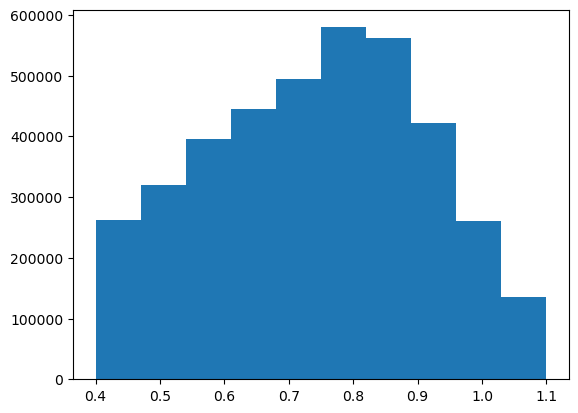

In [8]:
plt.hist(lrgtab["Z"])
#plt.hist(elgtab2['Z'])

In [3]:
file2 = "/global/cfs/cdirs/desi/survey/catalogs/Y1/mocks/SecondGenMocks/AbacusSummit_v4_2/forFA17.fits"
tab2 = Table(fitsio.read(file2))
tab2 = tab2[(tab2["DESI_TARGET"]&0x20==0x20)]

In [2]:
file2 = "/global/cfs/cdirs/desi/vac/edr/lss/v2.0/LSScats/clustering/ELG_HIP_S_clustering.dat.fits"
tab3 = Table(fitsio.read(file2))

file2 = "/global/cfs/cdirs/desi/vac/edr/lss/v2.0/LSScats/clustering/ELG_HIPnotqso_S_clustering.dat.fits"
tab4 = Table(fitsio.read(file2))

file2 = "/global/cfs/cdirs/desi/vac/edr/lss/v2.0/LSScats/clustering/ELGnotqso_S_clustering.dat.fits"
tab5 = Table(fitsio.read(file2))

file2 = "/global/cfs/cdirs/desi/vac/edr/lss/v2.0/LSScats/clustering/ELG_S_clustering.dat.fits"
tab6 = Table(fitsio.read(file2))

In [24]:
print(len(tab3),len(tab4),len(tab5),len(tab6))

106698 103585 134068 137621


(array([15833763.,        0.,        0.,        0.,        0.,        0.,
               0.,        0.,        0.,  1759190.]),
 array([34. , 40.4, 46.8, 53.2, 59.6, 66. , 72.4, 78.8, 85.2, 91.6, 98. ]),
 <BarContainer object of 10 artists>)

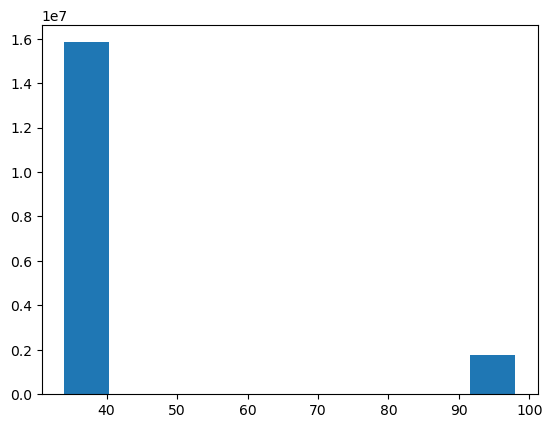

In [11]:
plt.hist(tab2['DESI_TARGET'])

(array([1.80309161, 2.10187779, 2.22429713, 3.0314348 , 3.21195145,
        2.9816371 , 3.26589895, 3.40491752, 3.82404814, 4.0626621 ,
        4.38219732, 4.40294636, 4.25355327, 4.19338106, 4.40917108,
        4.34277415, 4.39464675, 4.94449632, 4.78680361, 4.9382716 ,
        5.22668327, 4.98391949, 5.35325241, 4.84490092, 4.63118581]),
 array([0.75, 0.76, 0.77, 0.78, 0.79, 0.8 , 0.81, 0.82, 0.83, 0.84, 0.85,
        0.86, 0.87, 0.88, 0.89, 0.9 , 0.91, 0.92, 0.93, 0.94, 0.95, 0.96,
        0.97, 0.98, 0.99, 1.  ]),
 <BarContainer object of 25 artists>)

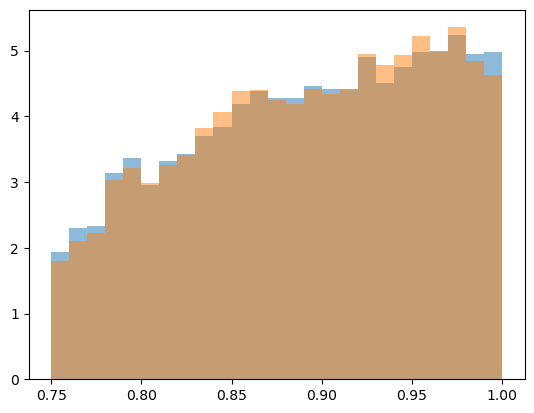

In [26]:
plt.hist(tab3['Z'],density=True,bins=np.arange(0.75,1.01,step=0.01),alpha=0.5)
plt.hist(tab6['Z'],density=True,bins=np.arange(0.75,1.01,step=0.01),alpha=0.5)

Text(0.5, 1.0, 'NTILE in Abacus ELG Catalog with Fiber Assign (North)')

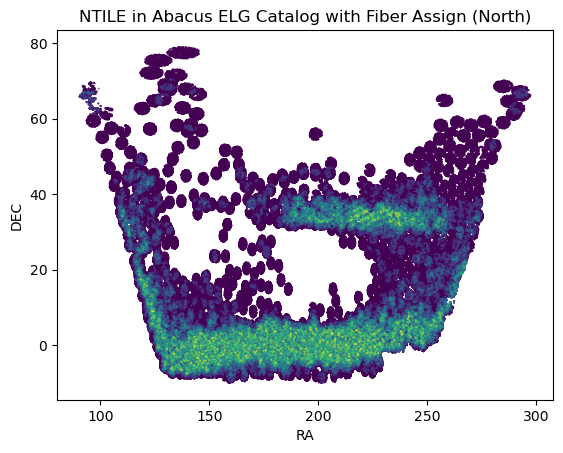

In [14]:
plt.scatter(elgtab["RA"],elgtab['DEC'],c = elgtab['NTILE'],s=0.1)
plt.xlabel("RA")
plt.ylabel("DEC")
plt.title("NTILE in Abacus ELG Catalog with Fiber Assign (North)")

Text(0.5, 1.0, 'NTILE in Abacus ELG Catalog with Fiber Assign (North)')

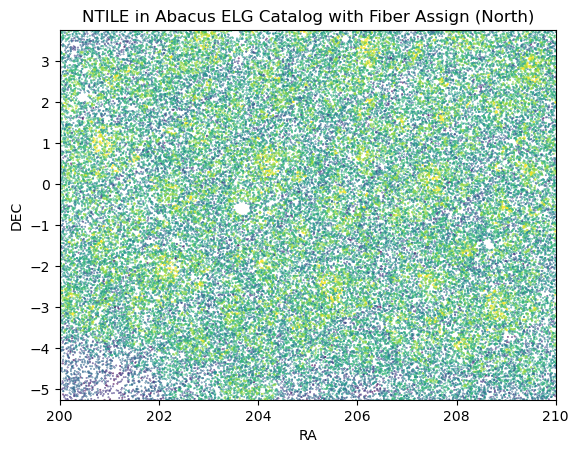

In [18]:
'''ralim = [130,223]
declim  = [-5.25,3.75]'''
ralim = [200,210]
declim  = [-5.25,3.75]

plt.ylim(*declim)
plt.xlim(*ralim)
plt.scatter(elgtab["RA"],elgtab['DEC'],c = elgtab['NTILE'],s=0.1)
plt.xlabel("RA")
plt.ylabel("DEC")
plt.title("NTILE in Abacus ELG Catalog with Fiber Assign (North)")

Text(0.5, 1.0, 'NTILE in Abacus ELG Catalog with Fiber Assign (North)')

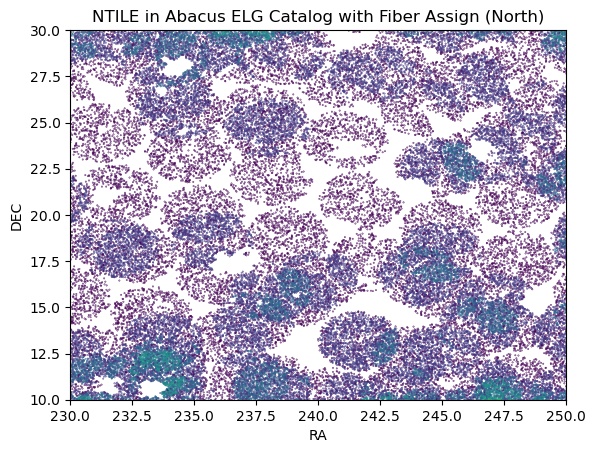

In [16]:
ralim = [230,250]
declim  = [10,30]

plt.ylim(*declim)
plt.xlim(*ralim)
plt.scatter(elgtab["RA"],elgtab['DEC'],c = elgtab['NTILE'],s=0.1)
plt.xlabel("RA")
plt.ylabel("DEC")
plt.title("NTILE in Abacus ELG Catalog with Fiber Assign (North)")

In [21]:
elgtabcut = elgtab[(elgtab['RA'] > ralim[0])&(elgtab['RA'] < ralim[1])&(elgtab['DEC'] > declim[0])&(elgtab['DEC'] < declim[1])]

(array([    0.,   155.,  1838.,  8634., 19838., 22683., 12737.]),
 array([0., 1., 2., 3., 4., 5., 6., 7.]),
 <BarContainer object of 7 artists>)

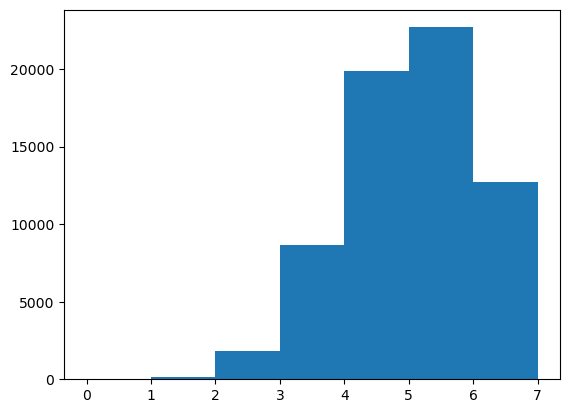

In [24]:
plt.hist(elgtabcut['NTILE'],bins=np.arange(8))

In [29]:
#forFA rands
randir = "/global/cfs/cdirs/desi/survey/catalogs/Y1/mocks/SecondGenMocks/AbacusSummit_v4_2/mock1/"
elgtable = []
lrgtable = []
ra1 = 150.1
dec1 = 2.182
stepsize = 0.01
sidelength = 0.5
nsteps = int(sidelength/stepsize)
for i in np.arange(1):
    efile = randir+'ELG_LOP_complete_clustering.dat.fits'
    lfile = randir+'LRG_complete_clustering.dat.fits'
    spe = Table(fitsio.read(efile))
    spl = Table(fitsio.read(lfile))
    elgcut = spe[(spe['RA'] > ra1-nsteps*stepsize)&(spe['RA']<ra1+nsteps*stepsize)&(spe['DEC']>dec1-nsteps*stepsize)&(spe['DEC']<dec1+nsteps*stepsize)]
    lrgcut = spl[(spl['RA'] > ra1-nsteps*stepsize)&(spl['RA']<ra1+nsteps*stepsize)&(spl['DEC']>dec1-nsteps*stepsize)&(spl['DEC']<dec1+nsteps*stepsize)]
    elgtable.append(elgcut)
    lrgtable.append(lrgcut)
    #table1.append(splN)
    #table1.append(splS)
randelg = vstack(elgtable)
randlrg = vstack(lrgtable)

In [30]:
randelg = vstack(elgtable)
randlrg = vstack(lrgtable)

In [31]:
randelg[0]

LOCATION,FIBER,TARGETID,RA,DEC,Z,PRIORITY_INIT,PRIORITY,DESI_TARGET,BRICKID,NOBS_G,NOBS_R,NOBS_Z,MASKBITS,ZWARN,COLLISION,TILEID,PHOTSYS,WEIGHT_SYS,WEIGHT_COMP,WEIGHT_ZFAIL,WEIGHT,NTILE,NX,WEIGHT_FKP
int64,int64,int64,float32,float32,float32,int64,int64,int64,int64,int64,int64,int64,int16,int64,bool,int64,str1,float64,float64,float64,float64,int64,float64,float64
7468,3638,50070,150.55211,1.930748,0.9522596,3100,3100,34,342490,4,4,4,0,0,False,2521,S,1.0,1.0,1.0,1.0,1,0.0009210451943163936,0.2134845018905862


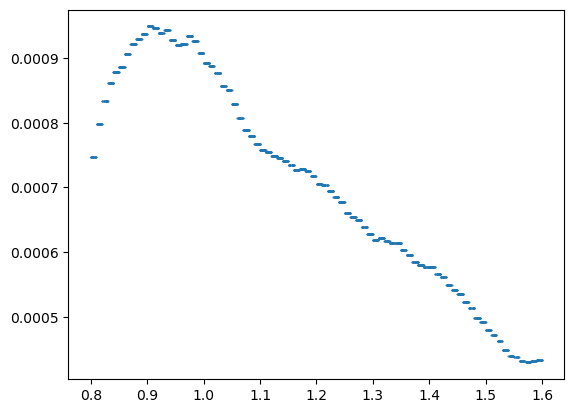

In [26]:
plt.scatter(randelg['Z'],randelg['NX'],s=0.2)

Text(0.5, 1.0, 'Galaxy Distribution in 18 Combined Random Y1 Catalogs (Abacus forFA)')

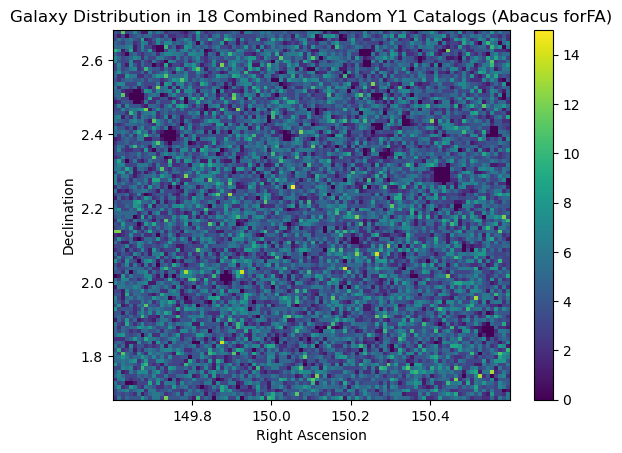

In [13]:
hist1,binsy,binsx = np.histogram2d(randelg['DEC'],randelg['RA'],bins=2*nsteps)
fig, ax = plt.subplots(1)
pc = ax.pcolormesh(binsx,binsy,hist1)
cbar = plt.colorbar(pc)
plt.xlabel("Right Ascension")
plt.ylabel("Declination")
plt.title("Galaxy Distribution in 18 Combined Random Y1 Catalogs (Abacus forFA)")

In [4]:
'''mockdir = "/global/cfs/cdirs/desi//survey/catalogs/Y1/mocks/SecondGenMocks/AbacusSummit_v4_2/"
file = mockdir + "forFA0_matched_input_full_lrg_imask.fits"
file2 = mockdir + "forFA0.fits"
sp = Table(fitsio.read(file))
sp2 = Table(fitsio.read(file2))'''
sv3file = '/global/cfs/cdirs/desi/vac/edr/lss/v2.0/LSScats/clustering/ELG_HIPnotqso_N_clustering.dat.fits'
spelg = Table(fitsio.read(sv3file))
sv3file = '/global/cfs/cdirs/desi/vac/edr/lss/v2.0/LSScats/clustering/LRG_main_N_clustering.dat.fits'
splrg = Table(fitsio.read(sv3file))

In [6]:
spelg[0]

RA,DEC,TARGETID,NTILE,TILES,Z,COMP_TILE,ROSETTE_NUMBER,ROSETTE_R,FRACZ_TILELOCID,BITWEIGHTS,PROB_OBS,WEIGHT_ZFAIL,WEIGHT,NZ,WEIGHT_FKP
float64,float64,int64,int64,str51,float64,float64,int32,float64,float64,int64[2],float64,float64,float64,float64,float64
218.20246586879503,52.922494359765516,39633293741655168,1,163,1.189585591915702,0.25,6,1.6907601356912527,0.3333333333333333,-9222720120814370304 .. -8931868274987597824,0.2109375,1.0,4.607142857142857,0.0005486461028484487,0.33244021493182796


(array([  204.,   729.,  1521.,  2235.,  3058.,  3728.,  4444.,  5155.,
         5952.,  6611.,  7304.,  8310.,  8775.,  9542., 10009., 10246.,
         8531.,  5479.,  1655.,    97.]),
 array([0.003253  , 0.09513524, 0.18701748, 0.27889972, 0.37078197,
        0.46266421, 0.55454645, 0.64642869, 0.73831094, 0.83019318,
        0.92207542, 1.01395767, 1.10583991, 1.19772215, 1.28960439,
        1.38148664, 1.47336888, 1.56525112, 1.65713336, 1.74901561,
        1.84089785]),
 <BarContainer object of 20 artists>)

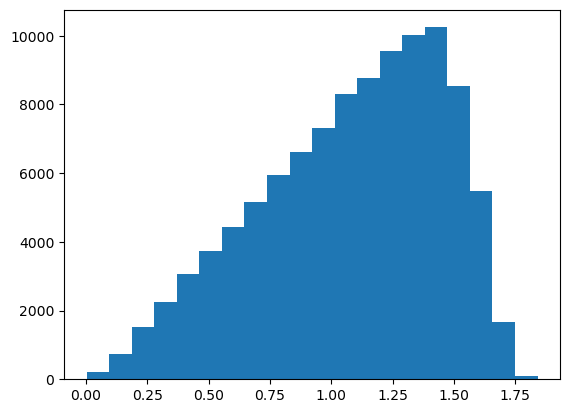

In [7]:
sp1 = 

plt.hist(sp["ROSETTE_R"],bins=20)
plt.hist(sp["ROSETTE_R"],bins=20)

In [43]:
zlim = [0.75,1]
spelg = spelg[(spelg['Z'] > zlim[0])&(spelg['Z'] < zlim[1])]
splrg = splrg[(splrg['Z'] > zlim[0])&(splrg['Z'] < zlim[1])]

Text(0.5, 1.0, 'Distribution of Galaxies across Rosettes')

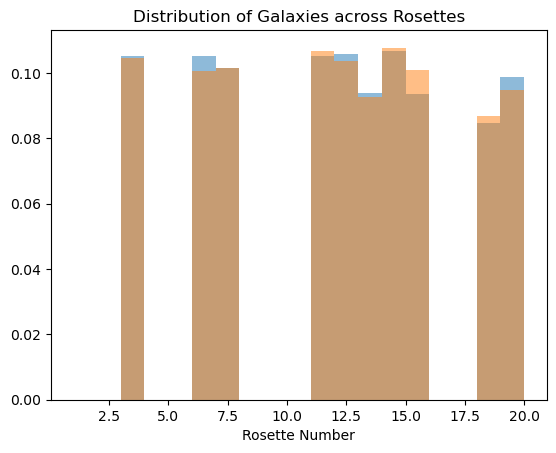

In [46]:
plt.hist(spelg['ROSETTE_NUMBER'],bins=np.arange(1,21),density=True,alpha=0.5,label= "ELG")
plt.hist(splrg['ROSETTE_NUMBER'],bins=np.arange(1,21),density = True,alpha =0.5,label="LRG")
plt.xlabel("Rosette Number")
plt.title("Distribution of Galaxies across Rosettes")

3290
2646


54.772255750516614

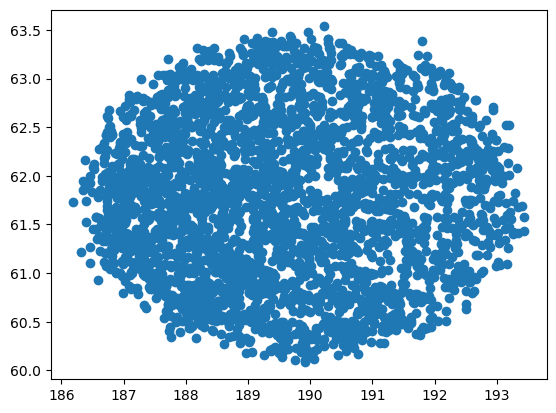

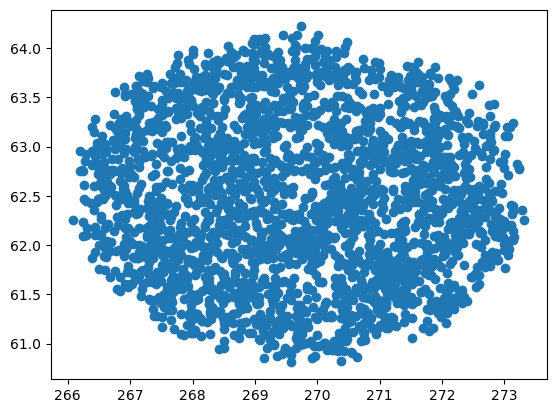

In [30]:
sp1 = sp[(sp['ROSETTE_NUMBER'] == 3)&(sp["Z"] > zlim[0])&(sp["Z"] < zlim[1])]
sp2 = sp[(sp['ROSETTE_NUMBER'] == 18)&(sp["Z"] > zlim[0])&(sp["Z"] < zlim[1])]
plt.figure()
plt.scatter(sp1['RA'],sp1['DEC'])
print(len(sp1))
plt.figure()
plt.scatter(sp2['RA'],sp2['DEC'])
print(len(sp2))

np.sqrt(3000)

In [33]:
#forFA finding ntile
dirr = "/global/cfs/cdirs/desi/survey/catalogs/Y1/mocks/SecondGenMocks/AbacusSummit_v4_2/mock1/"
mockfile = dirr + "ffa_full_ELG_LOP.fits"
table = Table(fitsio.read(mockfile))

Text(0.5, 1.0, 'NTile in Abacus FFA Mock')

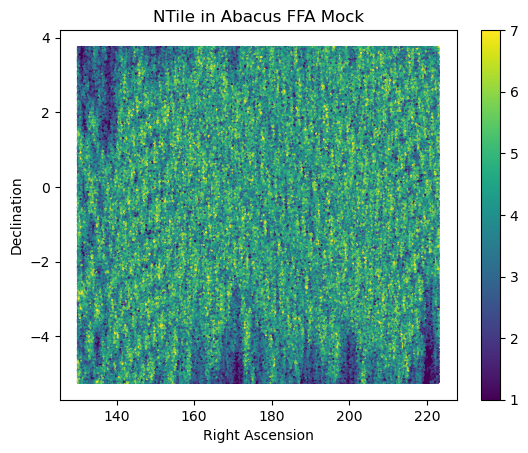

In [38]:
fig, ax = plt.subplots(1)
ralim = [130,223]
declim  = [-5.25,3.75]
tablecut = table[(table['RA'] > ralim[0])&(table['RA']<ralim[1])&\
                (table['DEC'] > declim[0])&(table['DEC']<declim[1])]
plt.plot()
im = plt.scatter(tablecut['RA'],tablecut['DEC'],c = tablecut['NTILE'],s=0.2)
#im = plt.scatter(table['RA'],table['DEC'],c = table['NTILE'],s=0.2)
cbar = fig.colorbar(im)
plt.xlabel("Right Ascension")
plt.ylabel("Declination")
plt.title("NTile in Abacus FFA Mock")

In [10]:
#Uchuu
uchuufile1 = '/global/cfs/cdirs/desi/public/edr/vac/edr/uchuu/v1.0/ELG_Uchuu/ELG_N_0_uchuu.dat.fits'
#'file = "/global/cfs/cdirs/desi/mocks/cai/Uchuu-SHAM/Y3-v1.5/0000/Uchuu-SHAM_ELG_Y3-v1.5_0000_clustering.dat.fits
uchuufile2 = '/global/cfs/cdirs/desi/public/edr/vac/edr/uchuu/v1.0/ELG_Uchuu/ELG_S_0_uchuu.dat.fits'

uchuutable1 = Table(fitsio.read(uchuufile1))
uchuutable2 = Table(fitsio.read(uchuufile2))

sv3fileN = '/global/cfs/cdirs/desi/vac/edr/lss/v2.0/LSScats/clustering/ELGnotqso_N_clustering.dat.fits'
sv3fileS = '/global/cfs/cdirs/desi/vac/edr/lss/v2.0/LSScats/clustering/ELGnotqso_S_clustering.dat.fits'
spN = Table(fitsio.read(sv3fileN))
spS = Table(fitsio.read(sv3fileS))



In [11]:
spN[0]

RA,DEC,TARGETID,NTILE,TILES,Z,COMP_TILE,ROSETTE_NUMBER,ROSETTE_R,FRACZ_TILELOCID,BITWEIGHTS,PROB_OBS,WEIGHT_ZFAIL,WEIGHT,NZ,WEIGHT_FKP
float64,float64,int64,int64,str51,float64,float64,int32,float64,float64,int64[2],float64,float64,float64,float64,float64
216.16662763301923,54.12203215060121,39633308149089719,1,163,1.2702485313076721,0.2,6,1.6701960209234223,0.25,1734218201111730496 .. 5562396380536833200,0.3125,1.0,3.1463414634146343,0.0004981710097899612,0.3564744247970895


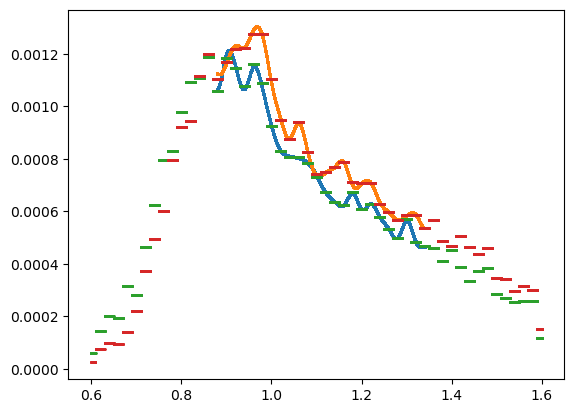

In [36]:
plt.scatter(uchuutable1['Z'],uchuutable1['NZ'],s=1)
plt.scatter(uchuutable2['Z'],uchuutable2['NZ'],s=1)
plt.scatter(spN['Z'],spN['NZ'],s=1)
plt.scatter(spS['Z'],spS['NZ'],s=1)

In [40]:
#Uchuu
uchuufile1 = '/global/cfs/cdirs/desi/public/edr/vac/edr/uchuu/v1.0/LRG_main_Uchuu/LRG_main_N_0_uchuu.dat.fits'
#'file = "/global/cfs/cdirs/desi/mocks/cai/Uchuu-SHAM/Y3-v1.5/0000/Uchuu-SHAM_ELG_Y3-v1.5_0000_clustering.dat.fits
uchuufile2 = '/global/cfs/cdirs/desi/public/edr/vac/edr/uchuu/v1.0/LRG_main_Uchuu/LRG_main_S_0_uchuu.dat.fits'

uchuutable1 = Table(fitsio.read(uchuufile1))
uchuutable2 = Table(fitsio.read(uchuufile2))

sv3fileN = '/global/cfs/cdirs/desi/vac/edr/lss/v2.0/LSScats/clustering/LRG_main_N_clustering.dat.fits'
sv3fileS = '/global/cfs/cdirs/desi/vac/edr/lss/v2.0/LSScats/clustering/LRG_main_S_clustering.dat.fits'
spN = Table(fitsio.read(sv3fileN))
spS = Table(fitsio.read(sv3fileS))

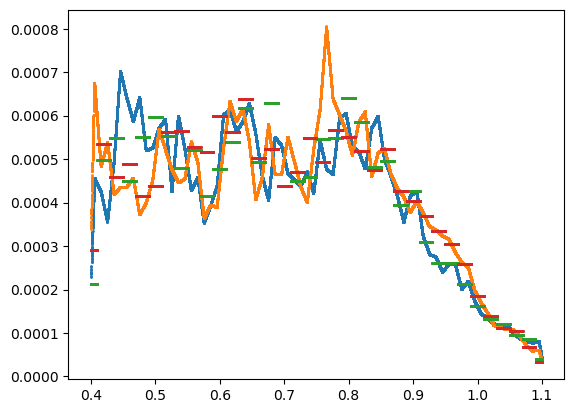

In [41]:
plt.scatter(uchuutable1['Z'],uchuutable1['NZ'],s=1)
plt.scatter(uchuutable2['Z'],uchuutable2['NZ'],s=1)
plt.scatter(spN['Z'],spN['NZ'],s=1)
plt.scatter(spS['Z'],spS['NZ'],s=1)

(array([ 1099.,  6098., 11700., 14594., 13539., 13034., 12401., 11801.,
        11004.,  8315.]),
 array([0.60009858, 0.70008666, 0.80007473, 0.90006281, 1.00005089,
        1.10003897, 1.20002705, 1.30001513, 1.40000321, 1.49999129,
        1.59997937]),
 <BarContainer object of 10 artists>)

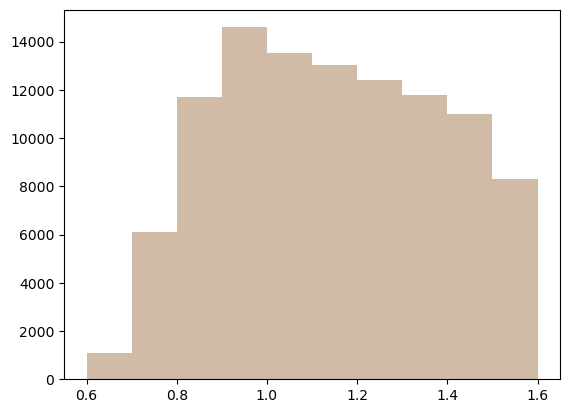

In [20]:
plt.hist(uchuutable1['Z'],alpha=0.3)
plt.hist(sp['Z'],alpha=0.3)

In [22]:
uchuucut = uchuutable[(uchuutable['Z'] > 0.9)&(uchuutable['Z'] < 1)& \
            (uchuutable['RA'] > 205)&(uchuutable['RA'] < 215)&(uchuutable['DEC'] > 2)&(uchuutable['DEC'] < 7)]
sv3cut = sv3table[(sv3table['Z'] > 0.9)&(sv3table['Z'] < 1)& \
            (sv3table['RA'] > 205)&(sv3table['RA'] < 215)&(sv3table['DEC'] > 2)&(sv3table['DEC'] < 7)]

In [23]:
print(len(uchuucut))
print(len(sv3cut))

2618
1463


In [20]:
uchuucut[:10]

RA,DEC,Z,NZ,WEIGHT_FKP
float64,float64,float64,float64,float64
211.20870721607363,4.8585294492780235,0.9041249748943908,0.00118530106347071,0.17417948496148503
210.78684886192437,5.029016903883473,0.9267010643355096,0.00123084018818469,0.16882307894848952
211.02455597281642,5.73804347325688,0.9229503143583268,0.0012335019287764933,0.16852017186535478
211.2746874896777,4.866788342076504,0.9226057224582314,0.0012335868850866663,0.16851052170456185
211.09993592311335,3.8838317869512053,0.9303739809869712,0.0012266988061707526,0.1692965410111479
211.6064580868569,4.916298539124071,0.9582512033618368,0.0012878929503732368,0.16256007932107797
211.60280602528087,5.403003655764479,0.9576599289226078,0.0012858704204527097,0.16277414856802216
211.6228432112312,5.5168979340554785,0.9049561515813236,0.0011889141647200795,0.1737421217537559
211.06699864439256,4.806156938105033,0.908387158401877,0.001203145629091921,0.17204056840209914


Text(0, 0.5, 'Declination (Degrees)')

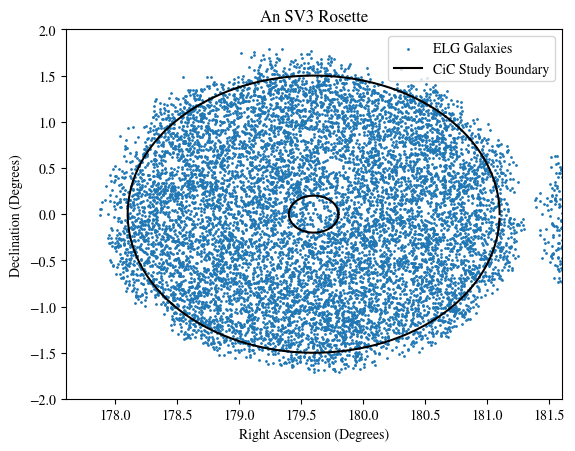

In [10]:
sv3cut = tab3

matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
matplotlib.fontsize = 12

plt.figure()
plt.scatter(sv3cut['RA'],sv3cut['DEC'],label='ELG Galaxies',s=1)

ra = 179.6
dec = 0
plt.xlim(ra-2,ra+2)
plt.ylim(dec-2,dec+2)
rosettera=ra
rosettedec=dec

thetas = np.arange(0,2*np.pi,step=0.05)
xs = np.cos(thetas)*1.5+rosettera
ys = np.sin(thetas)*1.5+rosettedec
plt.plot(xs,ys,color='black',label='CiC Study Boundary')

thetas = np.arange(0,2*np.pi,step=0.05)
xs = np.cos(thetas)*0.2+rosettera
ys = np.sin(thetas)*0.2+rosettedec
plt.plot(xs,ys,color='black')
plt.title("An SV3 Rosette")
plt.legend()
plt.xlabel("Right Ascension (Degrees)")
plt.ylabel("Declination (Degrees)")

In [15]:
#Aurelio's mock
file =  "/global/cfs/cdirs/desi/users/acarnero/CIC_mocks/Y1/fiducial/forFA0.fits"
sp = Table(fitsio.read(file))
file2 = "/global/cfs/cdirs/desi/users/acarnero/CIC_mocks/Y1/fiducial/randoms/fidran0_Y1.fits"
sp2 = Table(fitsio.read(file2))

In [48]:
print(110/129)
114/178
704

0.8527131782945736


0.6404494382022472

In [5]:
#randoms
file = "/global/cfs/cdirs/desi/target/catalogs/dr9/2.4.0/randoms/resolve/randoms-1-0/randoms-1-hp-286.fits"
sp3 = Table(fitsio.read(file))

In [16]:
sp[1]

RA,DEC,TRUEZ,STATUS,RSDZ,PRIORITY_INIT,PRIORITY,DESI_TARGET,NUMOBS_MORE,NUMOBS_INIT,TARGETID,BRICKID,NOBS_G,NOBS_R,NOBS_Z,MASKBITS,BGS_TARGET,MWS_TARGET,SUBPRIORITY,BRICKNAME,OBSCONDITIONS,SCND_TARGET,ZWARN
float32,float32,float32,int32,float32,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int16,int64,int64,float64,str8,int64,int64,int64
43.508698,2.4558792,0.01626685,15,0.016828949,3100,3100,34,2,2,30076102,344942,8,8,8,0,0,0,0.15012779740313054,000p0000,1,0,0


In [8]:
sp2[0]

RA,DEC
float64,float64
2.563238986993774,-13.765964039403194


In [5]:
file = "/global/cfs/cdirs/desi/spectro/redux/kibo/zcatalog/v1/zpix-sv3-dark.fits"
#columns = ['TARGET_RA','TARGET_DEC','Z','ZWARN','TARGETID', 'HEALPIX', 'CHI2','DELTACHI2', 'SPECTYPE','MORPHTYPE', 'FLUX_G','FLUX_R','FLUX_Z','EBV','FLUX_W1','FLUX_W2','FIBERFLUX_G','FIBERFLUX_R','FIBERFLUX_Z',"SV3_DESI_TARGET",'DESI_TARGET','BGS_TARGET']
sp = Table(fitsio.read(file))
#this object is an astropy table

In [6]:
sp[:5]

TARGETID,HEALPIX,SPGRPVAL,Z,ZERR,ZWARN,CHI2,COEFF,FITMETHOD,NPIXELS,SPECTYPE,SUBTYPE,NCOEFF,DELTACHI2,COADD_FIBERSTATUS,TARGET_RA,TARGET_DEC,DESINAME,PMRA,PMDEC,REF_EPOCH,FA_TARGET,FA_TYPE,OBJTYPE,SUBPRIORITY,OBSCONDITIONS,RELEASE,BRICKNAME,BRICKID,BRICK_OBJID,MORPHTYPE,EBV,FLUX_G,FLUX_R,FLUX_Z,FLUX_W1,FLUX_W2,FLUX_IVAR_G,FLUX_IVAR_R,FLUX_IVAR_Z,FLUX_IVAR_W1,FLUX_IVAR_W2,FIBERFLUX_G,FIBERFLUX_R,FIBERFLUX_Z,FIBERTOTFLUX_G,FIBERTOTFLUX_R,FIBERTOTFLUX_Z,MASKBITS,SERSIC,SHAPE_R,SHAPE_E1,SHAPE_E2,REF_ID,REF_CAT,GAIA_PHOT_G_MEAN_MAG,GAIA_PHOT_BP_MEAN_MAG,GAIA_PHOT_RP_MEAN_MAG,PARALLAX,PHOTSYS,PRIORITY_INIT,NUMOBS_INIT,SV3_DESI_TARGET,SV3_BGS_TARGET,SV3_MWS_TARGET,SV3_SCND_TARGET,DESI_TARGET,BGS_TARGET,MWS_TARGET,PLATE_RA,PLATE_DEC,COADD_NUMEXP,COADD_EXPTIME,COADD_NUMNIGHT,COADD_NUMTILE,MEAN_DELTA_X,RMS_DELTA_X,MEAN_DELTA_Y,RMS_DELTA_Y,MEAN_PSF_TO_FIBER_SPECFLUX,MEAN_FIBER_RA,STD_FIBER_RA,MEAN_FIBER_DEC,STD_FIBER_DEC,MIN_MJD,MAX_MJD,MEAN_MJD,TSNR2_BGS_B,TSNR2_ELG_B,TSNR2_GPBBACKUP_B,TSNR2_GPBBRIGHT_B,TSNR2_GPBDARK_B,TSNR2_LRG_B,TSNR2_LYA_B,TSNR2_QSO_B,TSNR2_BGS_R,TSNR2_ELG_R,TSNR2_GPBBACKUP_R,TSNR2_GPBBRIGHT_R,TSNR2_GPBDARK_R,TSNR2_LRG_R,TSNR2_LYA_R,TSNR2_QSO_R,TSNR2_BGS_Z,TSNR2_ELG_Z,TSNR2_GPBBACKUP_Z,TSNR2_GPBBRIGHT_Z,TSNR2_GPBDARK_Z,TSNR2_LRG_Z,TSNR2_LYA_Z,TSNR2_QSO_Z,TSNR2_BGS,TSNR2_ELG,TSNR2_GPBBACKUP,TSNR2_GPBBRIGHT,TSNR2_GPBDARK,TSNR2_LRG,TSNR2_LYA,TSNR2_QSO,ZCAT_NSPEC,ZCAT_PRIMARY
int64,int32,int32,float64,float64,int64,float64,float64[10],str4,int64,str6,str20,int64,float64,int32,float64,float64,str22,float32,float32,float32,int64,uint8,str3,float64,int32,int16,str8,int32,int32,str4,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int16,float32,float32,float32,float32,int64,str2,float32,float32,float32,float32,str1,int64,int64,int64,int64,int64,int64,int64,int64,int64,float64,float64,int16,float32,int16,int16,float32,float32,float32,float32,float32,float64,float32,float64,float32,float64,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int16,bool
39633166985596423,10016,10016,1.0562657006265288,2.8405863379751397e-05,0,7146.762395620346,10.619498879008233 .. 1.6082266550690263,PCA,7928,GALAXY,,10,208.42551517486572,0,246.13357978072827,45.096615692108,DESI J246.1335+45.0966,0.0,0.0,2015.5,4674,1,TGT,0.807080406975029,1,9011,2460p450,565022,3591,REX,0.008473855,0.41631913,0.42300114,0.97857475,0.5874997,1.0846462,295.18103,197.98474,90.81361,6.1939178,1.731049,0.23721759,0.24102497,0.5575894,0.23755646,0.24195033,0.55934715,0,1.0,0.41355485,0.0,0.0,0,,0.0,0.0,0.0,0.0,N,103100,9,4674,0,0,0,0,0,0,246.13357978072827,45.096615692108,2,1619.4482,2,2,0.0015,0.002915476,-0.0025,0.006041523,0.7723757,246.13358820802284,0.03557406,45.096624597916616,0.072603464,59311.4050539,59322.46143539,59316.933244645,1119.2507,0.20564795,368.4343,55.46463,297.38098,2.4611936,114.56244,5.358537,3976.1252,43.143627,20988.807,3524.3674,19757.354,62.119984,0.099950306,12.96272,9158.622,224.50606,5.4186105e-05,8.632504e-06,4.7446923e-05,101.4753,0.0,45.457256,14253.998,267.85535,21357.24,3579.832,20054.734,166.05649,114.66239,63.77851,1,True
39633166985595227,10016,10016,0.5144804904808535,1.4624027644111629e-05,0,6735.034863471985,85.15204844129876 .. 1.3552090376053245,PCA,7854,GALAXY,,10,370.1319229006767,0,246.03838931999678,45.03201944289077,DESI J246.0383+45.0320,0.0,0.0,2015.5,1028,1,TGT,0.27372766435951346,1,9011,2460p450,565022,2395,PSF,0.008809762,0.598748,1.3083286,1.4726115,4.086704,6.2245784,427.20355,232.39957,113.111435,6.680392,1.780357,0.4654771,1.0171173,1.1448338,0.4654771,1.0171173,1.1448338,0,0.0,0.0,0.0,0.0,0,,0.0,0.0,0.0,0.0,N,103400,4,1028,0,0,0,0,0,0,246.03838931999678,45.03201944289077,1,670.5653,1,1,0.0,0.0,-0.003,0.003,

In [17]:
file2 = "/global/cfs/cdirs/desi/survey/catalogs/Y1/mocks/SecondGenMocks/AbacusSummit_v4_2/forFA0_matched_input_full_lrg_imask.fits"
sp2 = Table(fitsio.read(file2))

In [18]:
sp2[1]

lrg_mask,TARGETID
uint8,int64
0,30076102


In [19]:
file2 = "/global/cfs/cdirs/desi/survey/catalogs/Y1/mocks/SecondGenMocks/AbacusSummit_v4_2/forFA0.fits"
sp2 = Table(fitsio.read(file2))

In [20]:
sp2[:1]

RA,DEC,TRUEZ,STATUS,RSDZ,PRIORITY_INIT,PRIORITY,DESI_TARGET,NUMOBS_MORE,NUMOBS_INIT,TARGETID,BRICKID,NOBS_G,NOBS_R,NOBS_Z,MASKBITS,BGS_TARGET,MWS_TARGET,SUBPRIORITY,BRICKNAME,OBSCONDITIONS,SCND_TARGET,ZWARN
float32,float32,float32,int32,float32,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int16,int64,int64,float64,str8,int64,int64,int64
64.46006,0.5625,0.015958173,15,0.016259655,3100,3100,34,2,2,9910024,333505,4,4,6,0,0,0,0.8376303749335617,000p0000,1,0,0


In [11]:
#Uchuuu
file3 = "/pscratch/sd/e/efdez/Uchuu/Y1/uchuu-desi-y3_v2_0p65_mask.txt"
df = pd.read_csv(file3, sep = ' ')
arr = df.to_numpy()
sp3 = Table(arr,)

In [13]:
file = "/pscratch/sd/h/hanyuz/ProjectElgSateProfile/mocks/AbacusSummit_base_c000_ph000/z0.950/galaxies_rsd_matchnz/ELGs.dat"
df = pd.read_csv(file, sep = ' ',skiprows=np.arange(15))
arr = df.to_numpy()
sp4 = Table(arr,names=['x','y','z','vx','vy','vz','mass','id'])

In [29]:
sp4['r'] = np.sqrt(sp4['x']**2 + sp4['y']**2 + sp4['z']**2)*cosmo.h

In [30]:
sp4[:10]

x,y,z,vx,vy,vz,mass,id,r2,r
float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
-999.3650512695312,-999.22119140625,-642.2208434886165,-281.2398986816406,-587.561279296875,-115.66291809082033,516724972511.0004,305003000.0,2409621.1068655085,1050.2830889986092
-998.4700317382812,-999.4196166992188,716.1986330348943,388.70947265625,103.76358795166016,198.11541748046875,331125798711.1309,1457004000.0,2508722.4564837087,1071.6631616654943
-999.8444213867188,-992.6424560546876,-535.449328207162,-173.5846405029297,325.2794189453125,-231.52825927734372,236217130290.74304,50397001000.0,2271733.895617926,1019.78993770493
-999.0470581054688,-993.7237548828124,-182.10752595179477,526.7294921875,-235.14593505859372,-439.9488525390625,544143032276.8903,50699000001.0,2018745.0763358711,961.3305273202407
-999.4486694335938,-991.8046264648438,478.7300966815929,528.427001953125,281.3174133300781,-320.0310363769531,622179048533.6536,61260000000.0,2211756.5653784163,1006.2378652081055
-999.4824829101562,-990.7191772460938,739.4035241035189,-130.25601196289062,-39.54612731933594,114.90119934082033,434470793213.331,71478002000.0,2527207.2932641306,1075.6040444315886
-999.8259887695312,-989.3342895507812,-367.133719346818,209.9170379638672,-44.761024475097656,605.554443359375,242544374852.10223,80532000000.0,2113221.512181348,983.5682588417591
-999.3838500976562,-989.06982421875,58.27623869479288,-350.52459716796875,-278.0328369140625,-496.3326416015625,246762537893.0084,90904000000.0,1980423.317012536,952.162359087081
-998.7220458984376,-986.0340576171876,-789.4996980900148,236.35667419433597,-179.77322387695312,262.2349548339844,202471825963.49405,110176002000.0,2593018.6610288005,1089.5190158353555


In [2]:
file5 = '/pscratch/sd/a/arocher/Abacus_LC/sky_patch_LRG-ELG-QSO-z0.4-2.1_nz+sky_dens.fits'
sp5 = Table(fitsio.read(file5))

In [15]:
file6 = '/global/cfs/cdirs/desi/vac/edr/lss/v2.0/LSScats/clustering/ELG_HIPnotqso_N_clustering.dat.fits'
sp6 = Table(fitsio.read(file6))
file7 = '/global/cfs/cdirs/desi/vac/edr/lss/v2.0/LSScats/clustering/LRG_main_N_clustering.dat.fits'
sp7 = Table(fitsio.read(file7))

file8 = '/global/cfs/cdirs/desi/vac/edr/lss/v2.0/LSScats/full/LRG_main_full.dat.fits'
sp8 = Table(fitsio.read(file8))

In [17]:
fails = len(sp8[sp8['ZWARN']==999999])
print(fails)
print(len(sp8))
print(fails/len(sp8))

4646
99935
0.04649021864211737


In [9]:
lrg2 = sp2[(sp2["DESI_TARGET"]&0x1==0x1)&(sp2["ZWARN"]==0)]
elg2 = sp2[(sp2["DESI_TARGET"]&0x2==0x2)&(sp2["ZWARN"]==0)]
#both = sp[(sp["DESI_TARGET"]&0x3==0x3)&(sp["ZWARN"]==0)]
print("Number of LRGs: "+str(len(lrg2)))
print("Number of ELGs: "+str(len(elg2)))
#print("Number of galaxies identified as both ELG and LRG: "+str(len(both)))'''
lrg = sp[(sp["ZWARN"]==0)]
print(len(sp2))[:1]

NameError: name 'sp2' is not defined

In [7]:
plt.hist(sp4['z'],bins=100)
plt.xlabel('Distance (Mpc)')
plt.ylabel("Galaxies")

NameError: name 'sp4' is not defined

(array([209., 223., 247., 286., 247., 293., 329., 251., 267., 285., 342.,
        345., 355., 421., 415., 335., 388., 379., 426., 390., 311., 341.,
        414., 387., 468., 287., 322., 268., 396., 503., 485., 437., 512.,
        556., 592., 546., 494., 446., 478., 673., 646., 530., 462., 433.,
        429., 444., 528., 467., 496., 570., 613., 593., 659., 571., 579.,
        654., 781., 729., 780., 739., 744., 698., 577., 589., 675., 629.,
        616., 584., 458., 521., 563., 597., 555., 473., 418., 384., 386.,
        343., 364., 367., 383., 346., 287., 341., 265., 251., 221., 210.,
        201., 186., 172., 203., 191., 163., 143., 137., 133., 131., 127.,
        128.]),
 array([0.40000305, 0.40700267, 0.41400229, 0.42100191, 0.42800153,
        0.43500115, 0.44200077, 0.44900039, 0.45600001, 0.46299963,
        0.46999925, 0.47699887, 0.48399849, 0.49099811, 0.49799774,
        0.50499736, 0.51199698, 0.5189966 , 0.52599622, 0.53299584,
        0.53999546, 0.54699508, 0.5539947 , 0.

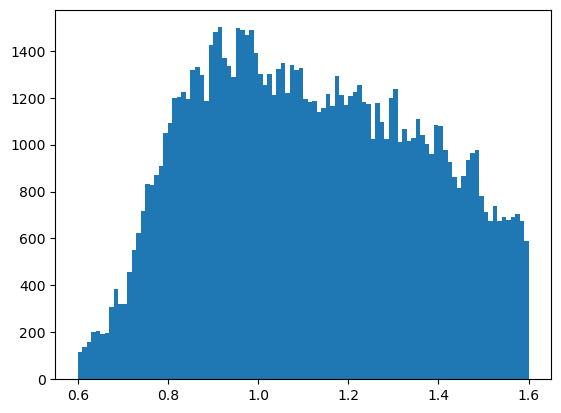

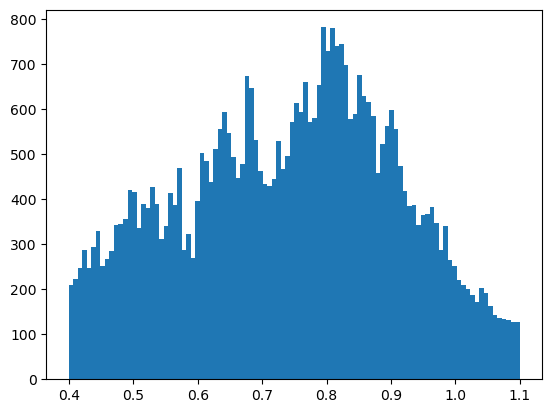

In [8]:
plt.figure()
plt.hist(sp6['Z'], bins = 100)
plt.figure()
plt.hist(sp7['Z'], bins = 100)

In [ ]:
slices = [[lrg[(lrg["RA"] > i*10)&(lrg["RA"] < (i+1)*10)&(lrg["DEC"] > j*10)&(lrg["DEC"] < (j+1)*10)] \
               for j in np.arange(-2,8)] for i in range(36)]

In [ ]:
slicesarray = np.array(slices)
for s in slicesarray.ravel():
    plt.figure()
    plt.title("Right Ascension-Declination Map of LRGs in Mock 0")
    plt.scatter(s["RA"],s["DEC"],s=1)
    #plt.scatter(elg["RA"],elg["DEC"],s=1,label="LRG")
    plt.xlabel("Right Ascension (Degrees)")
    plt.ylabel("Declination (Degrees)")

/global/common/software/desi/perlmutter/desiconda/20230111-2.1.0/conda/lib/python3.10/site-packages/IPython/core/events.py:89: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/global/common/software/desi/perlmutter/desiconda/20230111-2.1.0/conda/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


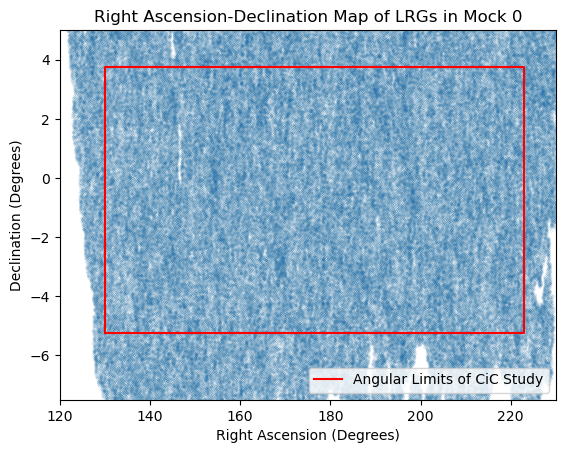

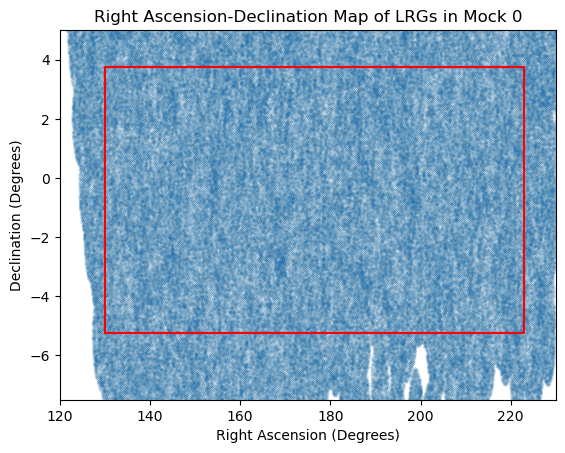

In [42]:
plt.figure()
plt.title("Right Ascension-Declination Map of LRGs in Mock 0")
plt.scatter(lrg["RA"],lrg["DEC"],s=0.001)
#plt.scatter(elg["RA"],elg["DEC"],s=1,label="LRG")
plt.xlabel("Right Ascension (Degrees)")
plt.ylabel("Declination (Degrees)")
plt.xlim(120,230)
#plt.xlim(140,150)
plt.ylim(-7.5,5)
#plt.ylim(-2,2)
plt.plot([130,223,223,130,130],[-5.25,-5.25,3.75,3.75,-5.25],color='red',label = "Angular Limits of CiC Study")
plt.legend()

plt.figure()
plt.title("Right Ascension-Declination Map of LRGs in Mock 0")
plt.scatter(lrg2["RA"],lrg2["DEC"],s=0.001)
#plt.scatter(elg["RA"],elg["DEC"],s=1,label="LRG")
plt.xlabel("Right Ascension (Degrees)")
plt.ylabel("Declination (Degrees)")
plt.xlim(120,230)
#plt.xlim(140,150)
plt.ylim(-7.5,5)
#plt.ylim(-2,2)
plt.plot([130,223,223,130,130],[-5.25,-5.25,3.75,3.75,-5.25],color='red')

Text(0, 0.5, 'Declination (Degrees)')

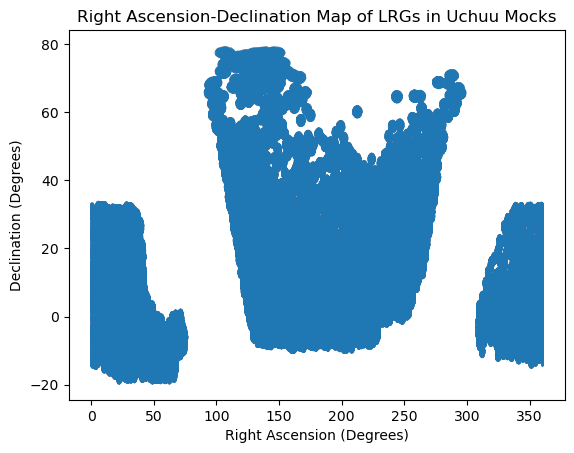

In [29]:
plt.figure()
plt.title("Right Ascension-Declination Map of LRGs in Uchuu Mocks")
plt.scatter(sp3["col3"],sp3["col4"],s=0.001)
plt.xlabel("Right Ascension (Degrees)")
plt.ylabel("Declination (Degrees)")

In [ ]:
#plot RA vs. DEC for LRGs and ELGs

'''
plt.figure()
plt.title("Right Ascension-Declination Map of LRGs in forFA mock")
plt.scatter(lrg["TARGET_RA"],lrg["TARGET_DEC"],s=3)
plt.xlabel("Right Ascension")
plt.ylabel("Declination")
'''

plt.figure()
plt.title("Right Ascension-Declination Map of LRGs in forFA mock")
plt.hist2d(lrg["RA"],lrg["DEC"],bins=200)
plt.xlabel("Right Ascension (Degrees)")
plt.ylabel("Declination (Degrees)")
'''
plt.figure()
plt.title("Right Ascension-Declination Map of LRGs in forFA mock")
plt.hist2d(lrg["RA"],lrg["DEC"],bins=(np.arange(192,198,0.1),np.arange(22,31,0.1)))
plt.xlabel("Right Ascension (Degrees)")
plt.ylabel("Declination (Degrees)")

'''
plt.figure()
plt.title("Right Ascension-Declination Map of LRGs in Mock 0")
plt.scatter(lrg["RA"],lrg["DEC"],s=1)
#plt.scatter(elg["RA"],elg["DEC"],s=1,label="LRG")
plt.xlabel("Right Ascension (Degrees)")
plt.ylabel("Declination (Degrees)")
plt.xlim(155,165)
plt.ylim(0,10)

In [38]:
#check number of galaxies within RA, DEC limits
ramin = 130
ramax = 223
decmin = -5.25
decmax = 3.75
splim = sp[(sp['RA'] > ramin)&(sp['RA'] < ramax)&(sp['DEC'] > decmin)&(sp['DEC'] < decmax)]
print(len(splim))
sp2lim = sp2[(sp2['RA'] > ramin)&(sp2['RA'] < ramax)&(sp2['DEC'] > decmin)&(sp2['DEC'] < decmax)]
print(len(sp2lim))

417586
2669549


In [ ]:
#make redshift histogram for lrgs and elgs

nbins = 500
#elgz = np.histogram(elg["Z"],bins=nbins)
#lrgz = np.histogram(lrg["Z"],bins=nbins)
plt.figure()
plt.title("ELG and LRG Redshift Cut for Counts in Cylinders")
plt.hist(elg["Z"],bins=100,label="ELG",alpha=0.7)
plt.xlabel("Redshift")
plt.ylabel("Galaxies")
plt.hist(lrg["Z"],bins=100,label="LRG",alpha=0.7)
plt.plot(np.repeat(0.75,2),[0,10**5],linewidth = 1, label = "Redshift Limits",color='red')
plt.plot(np.repeat(1,2),[0,10**5],linewidth = 1, color='red')

plt.legend()
plt.ylim(1,10**5)
plt.yscale("log")
plt.savefig("redshiftcut.png")

In [ ]:
#Example of adding columns to the astropy table from Daniel
elg['gr'] = -2.5*np.log10(elg['FLUX_G']/elg['FLUX_R'])-elg['EBV']*(3.214-2.165)
elg['rz'] = -2.5*np.log10(elg['FLUX_R']/elg['FLUX_Z'])-elg['EBV']*(2.165-1.211)
#-2.5*log(flux_g/flux_r) : magnitude difference in r and g color bands
#EBV part has to do with correcting for the Milky Way (?)

lrg['gr'] = -2.5*np.log10(lrg['FLUX_G']/lrg['FLUX_R'])-lrg['EBV']*(3.214-2.165)
lrg['rz'] = -2.5*np.log10(lrg['FLUX_R']/lrg['FLUX_Z'])-lrg['EBV']*(2.165-1.211)

#plot galaxy colors

plt.figure()
plt.title("ELG and LRG Galaxy Colors in DESI SV3")
plt.scatter(elg['gr'],elg['rz'],label="ELG",s=3)
plt.scatter(lrg['gr'],lrg['rz'],label="LRG",s=3)
plt.xlabel("G-R")
plt.ylabel("R-Z")
plt.legend()

#interpretation: the lower the magnitude, the greater the flux in G compared to R
#makes sense that LRGs have greater G-R then
#

In [ ]:
#Now time to calculate the Cartesian coordinates of a galaxy's position on the unit sphere

def raDecToUnitSphere(a, d):
    a = a*np.pi/180
    d = d*np.pi/180
    x = np.cos(a)*np.cos(d)
    y = np.sin(a)*np.cos(d)
    z = np.sin(d)
    return x,y,z

In [ ]:
elg['x'],elg['y'],elg['z'] = raDecToUnitSphere(elg['TARGET_RA'],elg['TARGET_DEC'])
lrg['x'],lrg['y'],lrg['z'] = raDecToUnitSphere(lrg['TARGET_RA'],lrg['TARGET_DEC'])

In [ ]:
fig = plt.figure(figsize=(10,6))
#ax.title("DESI SV3 LRGs on the Unit Sphere")
ax = fig.add_subplot(projection='3d')
ax.scatter(elg['x'],elg['y'],elg['z'],s=3)
plt.show()

In [ ]:
#now try to use scipyckdtree
'''
elgsphere = np.transpose([elg['x'],elg['y'],elg['z']])
lrgsphere = np.transpose([lrg['x'],lrg['y'],lrg['z']])
elgtree = cKDTree(elgsphere)
lrgtree = cKDTree(lrgsphere)'''

zlim = (elg["Z"]>0.8)&(elg["Z"]<1.2)
elg_z = elg[zlim]
elgsphere = np.transpose([elg_z['x'],elg_z['y'],elg_z['z']])
elgtree = cKDTree(elgsphere)
#print(len(elg_smallsquare))

Question: CiC paper from (?) describes weighting method to control for bias introduced by fiber collisions--do we need to worry about this?

In order to form our cylinders (i.e. find acceptable angular and line-of-sight separations between galaxies), we need to know the comoving distance between the galaxies. Not sure how to do that right now lol, so we will just form cells by choosing a maximum angular separation $\theta$ such that $\theta D_{z=1} = 1$ Mpc, where $D$ is the proper distance at $z=1$, $D \approx cz/H_0$. 

$$\theta = \frac{cz}{H_0}=\frac{1 \text{Mpc} * 74 \text{km}/\text{s}/\text{Mpc}}{3*10^5 \text{km}/\text{s}} \approx 50 \text{ arcseconds}$$

As far as the line-of-sight separation, we can plot the maximum difference in redshifts for galaxies grouped in one cylinder.

Another question: why do we want to do cylinders rather than spheres? I thought the point of the cylinder was that it reduced the problem to 2d (better computationally) but by putting things on the unit sphere we are going back to 3d anyway. Why can't we make a 3-d map in comoving space and then count neighbors in a spherical region around each galaxy?

Is it ok to be using 60 GB of memory?
ok the kernel died... i think I tried something too computationally intense. Let's try just one region of the sky between 24<dec<25 194<RA<195

In [ ]:
theta_CiC = 74/(3*10**5)

In [ ]:
elg_z['neighbors'] = elgtree.query_ball_point(elgsphere, theta_CiC)
#this will count the galaxy itself! not sure whether to remove it here or account for this problem in later logic

In [ ]:
elg_z['neighbor_z']=[{} for i in range(len(elg_z))]
elg_z['d_neighbor_z']=[{} for i in range(len(elg_z))]
for i in range(len(elg_z)):
    neighz = []
    dneighz = []
    for j in elg_z['neighbors'][i]:
        if j != i:
            neighz.append(elg_z['Z'][j]) #accounting for the galaxy itself appearing in neighbors list
            dneighz.append(elg_z['Z'][i]-elg_z['Z'][j])
    elg_z['neighbor_z'][i] = neighz
    elg_z['d_neighbor_z'][i] = dneighz

In [ ]:
elg_z['d'] = cosmo.comoving_distance(elg_z['Z'])
elg_z['neighbor_d']=[{} for i in range(len(elg_z))]
elg_z['d_neighbor_d']=[{} for i in range(len(elg_z))]
for i in range(len(elg_z)):
    neighz = []
    dneighz = []
    for j in elg_z['neighbors'][i]:
        if j != i:
            neighz.append(elg_z['d'][j]) #accounting for the galaxy itself appearing in neighbors list
            dneighz.append(elg_z['d'][i]-elg_z['d'][j])
    elg_z['neighbor_d'][i] = neighz
    elg_z['d_neighbor_d'][i] = dneighz

In [ ]:
d_diff = []
for i in range(len(elg_z)):
    for dd in elg_z['d_neighbor_d'][i]:
        d_diff.append(dd)
'''
z_diff = []
for i in range(len(elg_z)):
    for dz in elg_z['d_neighbor_z'][i]:
        z_diff.append(dz)'''
#plot average redshift difference between neighbors
plt.figure()
plt.hist(d_diff,bins = 100)
plt.title("Distance Between Neighbors in 50 Arcsecond Cylinders")#, 0.8 < z < 1.2 (ELGs)")
plt.xlabel(r"Comoving Distance Between Neighbors (Mpc)")
plt.ylabel("Galaxies")
plt.savefig("dZ.png")

plt.figure()
plt.hist(d_diff,bins = 100,range=(0,100))
plt.title("Distance Neighbors in 50 Arcsecond Cylinders")#, 0.8 < z < 1.2 (ELGs)")
plt.xlabel(r"Comoving Distance Between Neighbors (Mpc)")
plt.ylabel("Neighbor Pairs")

In [ ]:
elg_smallsquare['d_neighbor_z'].data

hi


In [4]:
elgdir = "/global/cfs/cdirs/desi/public/edr/vac/edr/uchuu/v1.0/ELG_Uchuu/"
lrgdir = "/global/cfs/cdirs/desi/public/edr/vac/edr/uchuu/v1.0/LRG_main_Uchuu/"
columns = ['RA','DEC','Z','NZ']
i = 2
elgfileN = elgdir+"ELG_N_"+str(i)+"_uchuu.dat.fits"
elgfileS = elgdir+"ELG_S_"+str(i)+"_uchuu.dat.fits"
lrgfileN = lrgdir+"LRG_main_N_"+str(i)+"_uchuu.dat.fits"
lrgfileS = lrgdir+"LRG_main_S_"+str(i)+"_uchuu.dat.fits"
spelgN = Table(fitsio.read(elgfileN, columns=columns))
spelgS = Table(fitsio.read(elgfileS, columns=columns))
splrgN = Table(fitsio.read(lrgfileN, columns=columns))
splrgS = Table(fitsio.read(lrgfileS, columns=columns))

(array([3319., 3943., 4884., 6334., 6197., 7917., 7542., 5363., 3267.,
        1835.]),
 array([0.40002262, 0.47001422, 0.54000582, 0.60999743, 0.67998903,
        0.74998063, 0.81997223, 0.88996383, 0.95995543, 1.02994703,
        1.09993863]),
 <BarContainer object of 10 artists>)

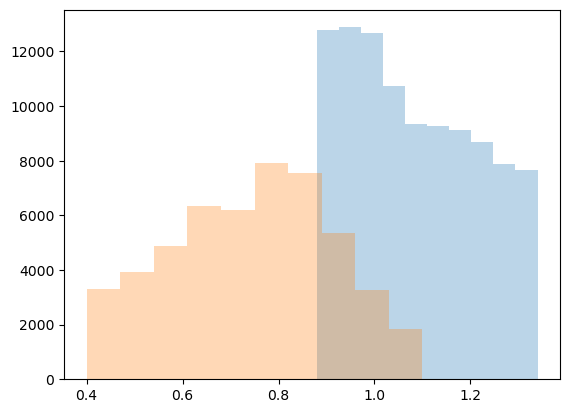

In [7]:
plt.hist(spelgN['Z'],alpha=0.3)
plt.hist(splrgN['Z'],alpha = 0.3)

In [8]:
spelg[0]

NameError: name 'spelg' is not defined